# 🔗 Postprocesado HMM: contexto temporal sobre las predicciones del Random Forest

**Notebook 3 del pipeline (postprocesado).** Se ejecuta después de:

1. `Reetiquetado_Hipnograma.ipynb` (notebook 0)
2. `Extraccion_Caracteristicas_Fases.ipynb` (notebook 1)
3. `Modelado_Fases_Sueno.ipynb` (notebook 2)

### Qué hace y por qué

El Random Forest del notebook 2 clasifica **cada época de 30 s de forma
independiente**: no usa información de las épocas vecinas. Pero el sueño
humano tiene una estructura temporal muy fuerte:

- N3 casi nunca pasa directamente a W; lo natural es N3 → N2 → N1 → W.
- N1 es una transición y aparece típicamente entre W y N2 o entre REM y W.
- REM dura típicamente 10-30 minutos en bloques contiguos.

Estas regularidades pueden modelarse con un **Modelo Oculto de Markov
(HMM)**: los estados ocultos son las fases reales, las observaciones son
las probabilidades del Random Forest, y la decodificación por **Viterbi**
encuentra la secuencia de fases globalmente más coherente.

### Ventajas frente a otras opciones de contexto temporal

| Opción | Implementación | Cómputo | $\kappa$ esperado |
|---|---|---|---|
| **HMM (este notebook)** | ~150 líneas, sklearn-compatible | Segundos | +0.05 a +0.08 |
| BiLSTM | ~250 líneas PyTorch | 1-3 h CPU | +0.06 a +0.12 |
| Transformer temporal | ~400 líneas | Horas en GPU | +0.07 a +0.15 |

El HMM es la opción con mejor relación costo/beneficio: **no entrena
ningún modelo pesado** (solo aprende dos matrices pequeñas), **no toca el
RF entrenado**, y ataca específicamente la confusión en N1 que es el
mayor problema del RF aislado.

### Resultado esperado en tus datos

Si el RF base te dio $\kappa = 0{,}62$ (AASM), tras HMM debería subir a
$\kappa \approx 0{,}67$ a $0{,}70$. La fase N1 (recall 0.11 en RF puro)
debería mejorar más que las otras porque el HMM aprende explícitamente
sus reglas de transición.

## 1. Importaciones y configuración

Reutilizamos exactamente las mismas rutas y parámetros del notebook 2
para garantizar consistencia.

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    cohen_kappa_score, confusion_matrix, classification_report,
)

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 110, 'figure.figsize': (13, 5),
    'axes.titlesize': 13, 'axes.labelsize': 11, 'font.size': 10,
})
sns.set_style('whitegrid')

RANDOM_STATE = 42
K_FOLDS = 5

# ── Rutas (idénticas al notebook 2) ──
FEATURES_DIR = Path.cwd() / '../data/features_fases'
RESULTS_DIR  = Path.cwd() / '../data/results_fases'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Clases ──
CLASES_RK   = ['W', 'S1', 'S2', 'S3', 'S4', 'REM']
CLASES_AASM = ['W', 'N1', 'N2', 'N3', 'REM']
MAPEO_RK_A_AASM = {'W':'W','S1':'N1','S2':'N2','S3':'N3','S4':'N3','REM':'REM'}

print(f'Folds        : {K_FOLDS}')
print(f'Clases R&K   : {CLASES_RK}')
print(f'Clases AASM  : {CLASES_AASM}')

Folds        : 5
Clases R&K   : ['W', 'S1', 'S2', 'S3', 'S4', 'REM']
Clases AASM  : ['W', 'N1', 'N2', 'N3', 'REM']


## 2. Recargar dataset y reproducir el RF base

Cargamos el dataset, lo colapsamos a nivel época (mismo proceso que el
notebook 2) y reproducimos la división por paciente.

In [2]:
# Cargar dataset por canal
df_raw = pd.read_csv(FEATURES_DIR / 'caracteristicas_fases_30s.csv')

# Colapsar por época (promedio entre canales)
META_COLS = ['patient', 'channel', 'epoch_idx', 'onset_s', 'stage']
FEAT_COLS = [c for c in df_raw.columns if c not in META_COLS]
df = (df_raw.groupby(['patient', 'epoch_idx', 'onset_s', 'stage'],
                      as_index=False)[FEAT_COLS].mean())

# Mapear a AASM
df['stage_aasm'] = df['stage'].map(MAPEO_RK_A_AASM)

# Ordenar dentro de cada paciente por épocas ─ CRÍTICO para HMM ─
df = df.sort_values(['patient', 'onset_s']).reset_index(drop=True)

# Limpieza (igual que notebook 2)
X = df[FEAT_COLS].copy()
constantes = X.columns[X.std() == 0].tolist()
if constantes:
    X = X.drop(columns=constantes)
    FEAT_COLS = [c for c in FEAT_COLS if c not in constantes]
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())

y_rk   = df['stage'].values
y_aasm = df['stage_aasm'].values
groups = df['patient'].values
onsets = df['onset_s'].values

print(f'Dataset colapsado: {len(df):,} épocas, {df["patient"].nunique()} pacientes')
print(f'Features         : {len(FEAT_COLS)}')

Dataset colapsado: 102,489 épocas, 102 pacientes
Features         : 32


## 3. Teoría del HMM aplicado a sleep staging

### Modelo

Sea $Z_1, Z_2, \ldots, Z_T$ la secuencia de fases reales (estados
ocultos) de una noche y $O_1, O_2, \ldots, O_T$ las observaciones
correspondientes. Un HMM modela esta secuencia con tres componentes:

1. **Distribución inicial $\pi_i = P(Z_1 = i)$**: probabilidad de que la
   noche empiece en cada fase. Casi siempre $\pi_W \approx 1$ (el
   paciente se acuesta despierto).

2. **Matriz de transición $A_{ij} = P(Z_t = j \mid Z_{t-1} = i)$**:
   probabilidad de pasar de la fase $i$ en la época $t-1$ a la fase $j$
   en la época $t$. Es donde se codifica la estructura del sueño (p. ej.
   $A_{N3, W}$ es baja, $A_{N3, N2}$ es alta).

3. **Distribución de emisión $B_i(o)$**: probabilidad de observar $o$
   dado que el estado real es $i$. En nuestro caso, en lugar de modelar
   $P(\mathrm{features} \mid \mathrm{fase})$ —que sería complicado—,
   **usamos las probabilidades posteriores del Random Forest**
   $P(\mathrm{fase} \mid \mathrm{features})$ directamente como emisiones,
   convirtiendo el HMM en un *postprocesado discriminativo*.

### Aprendizaje (sin supervisión iterativa)

Como tenemos las etiquetas verdaderas en el conjunto de entrenamiento,
**no necesitamos Baum-Welch**: estimamos $\pi$ y $A$ directamente por
conteo de frecuencias en los hipnogramas de entrenamiento. Se llama a
esto **HMM supervisado** o aprendizaje por máxima verosimilitud completa.

### Decodificación con Viterbi

Para una secuencia de observaciones $O_1, \ldots, O_T$, queremos la
secuencia de estados $\hat{Z}_1, \ldots, \hat{Z}_T$ más probable:

$$
\hat{Z}_{1:T} = \arg\max_{Z_{1:T}} P(Z_{1:T} \mid O_{1:T})
$$

El algoritmo de Viterbi resuelve esto en $\mathcal{O}(T K^2)$ donde
$K$ es el número de clases. Para 1000 épocas y 5 clases es
prácticamente instantáneo.

### Por qué ayuda específicamente con N1

N1 tiene un perfil EEG ambiguo (entre W y N2) pero **una posición
temporal muy específica**: aparece en transiciones W→N2 al inicio del
sueño y en transiciones N2→REM o REM→W más tarde. El HMM aprende esto
en la matriz $A$ y lo aplica al decodificar.

## 4. Implementación del HMM

In [3]:
def aprender_transiciones(y_seq_por_paciente, clases, alpha=1.0):
    '''
    Estima la distribución inicial pi y la matriz de transición A
    contando frecuencias en las secuencias de entrenamiento.

    Parámetros
    ----------
    y_seq_por_paciente : lista de arrays
        Una secuencia de etiquetas por paciente, en orden temporal.
    clases : lista
        Nombres de las clases (define el orden de pi y A).
    alpha : float
        Suavizado de Laplace para evitar probabilidades 0
        (transiciones nunca observadas en train).

    Returns
    -------
    pi : array (K,)
        log-probabilidades iniciales.
    log_A : array (K, K)
        log-probabilidades de transición.
    '''
    K = len(clases)
    cls_to_idx = {c: i for i, c in enumerate(clases)}

    cuenta_pi = np.full(K, alpha)
    cuenta_A  = np.full((K, K), alpha)

    for seq in y_seq_por_paciente:
        if len(seq) == 0:
            continue
        cuenta_pi[cls_to_idx[seq[0]]] += 1
        for t in range(1, len(seq)):
            i = cls_to_idx[seq[t-1]]
            j = cls_to_idx[seq[t]]
            cuenta_A[i, j] += 1

    pi = cuenta_pi / cuenta_pi.sum()
    A  = cuenta_A / cuenta_A.sum(axis=1, keepdims=True)

    log_pi = np.log(pi)
    log_A  = np.log(A)
    return log_pi, log_A, A


def viterbi(log_pi, log_A, log_emisiones):
    '''
    Algoritmo de Viterbi para decodificar la secuencia óptima.

    Parámetros
    ----------
    log_pi : array (K,)
    log_A : array (K, K)
        log-transiciones (i,j) = log P(j|i).
    log_emisiones : array (T, K)
        log P(obs_t | estado_t = k) para t=1..T.

    Returns
    -------
    secuencia : array (T,) de índices de clase
    '''
    T, K = log_emisiones.shape

    # delta[t, k] = log-prob del mejor camino que termina en k en tiempo t
    delta = np.full((T, K), -np.inf)
    psi   = np.zeros((T, K), dtype=int)  # backpointer

    # Inicialización
    delta[0] = log_pi + log_emisiones[0]

    # Recurrencia
    for t in range(1, T):
        # delta[t-1, i] + log_A[i, j] da una matriz (K, K)
        scores = delta[t-1][:, None] + log_A           # (K, K)
        psi[t]   = scores.argmax(axis=0)               # mejor i para cada j
        delta[t] = scores.max(axis=0) + log_emisiones[t]

    # Backtracking
    seq = np.zeros(T, dtype=int)
    seq[-1] = delta[-1].argmax()
    for t in range(T - 2, -1, -1):
        seq[t] = psi[t + 1, seq[t + 1]]

    return seq


# Prueba rápida de los componentes con datos triviales
print('Test rápido del Viterbi:')
log_pi_test = np.log(np.array([0.9, 0.1]))
log_A_test = np.log(np.array([[0.8, 0.2], [0.3, 0.7]]))
log_em_test = np.log(np.array([[0.6, 0.4], [0.4, 0.6], [0.3, 0.7]]))
sec_test = viterbi(log_pi_test, log_A_test, log_em_test)
print(f'  Secuencia decodificada: {sec_test} (esperado: [0, 0, 1] o similar)')

Test rápido del Viterbi:
  Secuencia decodificada: [0 0 0] (esperado: [0, 0, 1] o similar)


## 5. Pipeline integrado: RF + HMM por fold

Para cada fold del `StratifiedGroupKFold`:

1. Entrenamos el RF sobre los pacientes de train.
2. Aprendemos $\pi$ y $A$ desde los hipnogramas de train.
3. Para cada paciente de test:
    - Obtenemos sus probabilidades por época: $P(\mathrm{fase}|x_t)$ del RF.
    - Aplicamos Viterbi sobre esa secuencia usando $\pi$, $A$ y las
      probabilidades del RF como emisiones (en log).
4. Comparamos contra la verdad y comparamos contra la predicción **sin
   HMM** del propio RF, en el mismo fold.

Así obtenemos directamente $\Delta\kappa$ aportado por el HMM.

In [4]:
def evaluar_rf_y_hmm(X, y, groups, onsets, clases, esquema, verbose=True):
    '''
    Evalúa Random Forest puro vs RF + HMM con StratifiedGroupKFold.
    Devuelve dos DataFrames de métricas por fold + matrices de confusión
    acumuladas para los dos métodos.
    '''
    cv = StratifiedGroupKFold(n_splits=K_FOLDS, shuffle=True,
                               random_state=RANDOM_STATE)

    filas_rf  = []
    filas_hmm = []
    cm_rf  = np.zeros((len(clases), len(clases)), dtype=int)
    cm_hmm = np.zeros((len(clases), len(clases)), dtype=int)

    for fold_i, (tr, te) in enumerate(cv.split(X, y, groups), 1):
        # === RF ===
        rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                     n_jobs=-1, random_state=RANDOM_STATE)
        rf.fit(X.iloc[tr], y[tr])

        # Asegurar orden consistente de clases
        clases_rf = list(rf.classes_)
        # Mapeo de índice RF → índice nuestro
        rf_to_clases = [clases_rf.index(c) for c in clases]

        # Predicciones del RF puro
        y_pred_rf = rf.predict(X.iloc[te])

        # Probabilidades del RF (matriz N_test × K, en el orden de 'clases')
        proba_rf = rf.predict_proba(X.iloc[te])[:, rf_to_clases]
        # Evitar log(0)
        proba_rf = np.clip(proba_rf, 1e-8, 1.0)
        log_em = np.log(proba_rf)

        # === Aprender HMM con etiquetas de train ===
        # Construir secuencias por paciente (orden temporal)
        df_tr = pd.DataFrame({
            'patient': groups[tr], 'onset_s': onsets[tr], 'y': y[tr]
        }).sort_values(['patient', 'onset_s'])
        seqs_train = [g['y'].values for _, g in df_tr.groupby('patient')]
        log_pi, log_A, A = aprender_transiciones(seqs_train, clases)

        # === Aplicar Viterbi por paciente de test ===
        df_te = pd.DataFrame({
            'patient': groups[te], 'onset_s': onsets[te],
            'idx_orig': np.arange(len(te)),
        }).sort_values(['patient', 'onset_s'])

        y_pred_hmm = np.array([None] * len(te), dtype=object)
        for pac, g in df_te.groupby('patient'):
            idx_pac = g['idx_orig'].values         # índices dentro de te
            log_em_pac = log_em[idx_pac]
            sec = viterbi(log_pi, log_A, log_em_pac)
            for pos, k in zip(idx_pac, sec):
                y_pred_hmm[pos] = clases[k]
        y_pred_hmm = y_pred_hmm.astype(str)

        # === Métricas ===
        y_te = y[te]
        # RF puro
        fila_rf = {
            'fold': fold_i,
            'accuracy': accuracy_score(y_te, y_pred_rf),
            'f1_macro': f1_score(y_te, y_pred_rf, labels=clases,
                                  average='macro', zero_division=0),
            'kappa': cohen_kappa_score(y_te, y_pred_rf, labels=clases),
        }
        # HMM
        fila_hmm = {
            'fold': fold_i,
            'accuracy': accuracy_score(y_te, y_pred_hmm),
            'f1_macro': f1_score(y_te, y_pred_hmm, labels=clases,
                                  average='macro', zero_division=0),
            'kappa': cohen_kappa_score(y_te, y_pred_hmm, labels=clases),
        }
        # Recall por clase
        rec_rf  = recall_score(y_te, y_pred_rf, labels=clases,
                                average=None, zero_division=0)
        rec_hmm = recall_score(y_te, y_pred_hmm, labels=clases,
                                average=None, zero_division=0)
        for cl, r_rf, r_hmm in zip(clases, rec_rf, rec_hmm):
            fila_rf[f'recall_{cl}']  = r_rf
            fila_hmm[f'recall_{cl}'] = r_hmm
        filas_rf.append(fila_rf)
        filas_hmm.append(fila_hmm)

        # Matrices de confusión
        cm_rf  += confusion_matrix(y_te, y_pred_rf,  labels=clases)
        cm_hmm += confusion_matrix(y_te, y_pred_hmm, labels=clases)

        if verbose:
            print(f'  Fold {fold_i}: RF κ={fila_rf["kappa"]:.3f}  →  '
                  f'HMM κ={fila_hmm["kappa"]:.3f}  '
                  f'(Δ={fila_hmm["kappa"]-fila_rf["kappa"]:+.3f})')

    df_rf  = pd.DataFrame(filas_rf)
    df_hmm = pd.DataFrame(filas_hmm)
    return df_rf, df_hmm, cm_rf, cm_hmm, A


# Ejecutar para AASM (5 clases) - resultado principal del artículo
print('═' * 65)
print('EVALUACIÓN AASM: Random Forest vs Random Forest + HMM')
print('═' * 65)
df_rf_aasm, df_hmm_aasm, cm_rf_aasm, cm_hmm_aasm, A_aasm = \
    evaluar_rf_y_hmm(X, y_aasm, groups, onsets, CLASES_AASM, 'AASM')

═════════════════════════════════════════════════════════════════
EVALUACIÓN AASM: Random Forest vs Random Forest + HMM
═════════════════════════════════════════════════════════════════
  Fold 1: RF κ=0.662  →  HMM κ=0.710  (Δ=+0.048)
  Fold 2: RF κ=0.632  →  HMM κ=0.677  (Δ=+0.045)
  Fold 3: RF κ=0.583  →  HMM κ=0.622  (Δ=+0.040)
  Fold 4: RF κ=0.644  →  HMM κ=0.708  (Δ=+0.063)
  Fold 5: RF κ=0.595  →  HMM κ=0.651  (Δ=+0.056)


In [5]:
# También para R&K (6 clases)
print('\n' + '═' * 65)
print('EVALUACIÓN R&K: Random Forest vs Random Forest + HMM')
print('═' * 65)
df_rf_rk, df_hmm_rk, cm_rf_rk, cm_hmm_rk, A_rk = \
    evaluar_rf_y_hmm(X, y_rk, groups, onsets, CLASES_RK, 'R&K')


═════════════════════════════════════════════════════════════════
EVALUACIÓN R&K: Random Forest vs Random Forest + HMM
═════════════════════════════════════════════════════════════════
  Fold 1: RF κ=0.607  →  HMM κ=0.642  (Δ=+0.035)
  Fold 2: RF κ=0.618  →  HMM κ=0.658  (Δ=+0.040)
  Fold 3: RF κ=0.584  →  HMM κ=0.624  (Δ=+0.040)
  Fold 4: RF κ=0.524  →  HMM κ=0.588  (Δ=+0.064)
  Fold 5: RF κ=0.559  →  HMM κ=0.615  (Δ=+0.055)


## 6. Resumen comparativo

In [6]:
def resumen_comp(df_rf, df_hmm, esquema):
    '''Resumen estadístico de las métricas de RF puro vs RF+HMM.'''
    metricas = ['accuracy', 'f1_macro', 'kappa']
    res = []
    for m in metricas:
        rf_mean, rf_std   = df_rf[m].mean(),  df_rf[m].std()
        hmm_mean, hmm_std = df_hmm[m].mean(), df_hmm[m].std()
        delta = hmm_mean - rf_mean
        res.append({'esquema': esquema, 'metrica': m,
                    'RF':  f'{rf_mean:.3f} ± {rf_std:.3f}',
                    'RF+HMM': f'{hmm_mean:.3f} ± {hmm_std:.3f}',
                    'Δ': f'{delta:+.3f}'})
    return pd.DataFrame(res)

resumen_aasm = resumen_comp(df_rf_aasm, df_hmm_aasm, 'AASM')
resumen_rk   = resumen_comp(df_rf_rk,   df_hmm_rk,   'R&K')

print('═══ AASM (5 clases) ═══')
print(resumen_aasm.to_string(index=False))
print('\n═══ R&K (6 clases) ═══')
print(resumen_rk.to_string(index=False))

═══ AASM (5 clases) ═══
esquema  metrica            RF        RF+HMM      Δ
   AASM accuracy 0.721 ± 0.025 0.761 ± 0.028 +0.040
   AASM f1_macro 0.620 ± 0.023 0.643 ± 0.028 +0.024
   AASM    kappa 0.623 ± 0.033 0.674 ± 0.038 +0.050

═══ R&K (6 clases) ═══
esquema  metrica            RF        RF+HMM      Δ
    R&K accuracy 0.679 ± 0.029 0.719 ± 0.020 +0.040
    R&K f1_macro 0.566 ± 0.025 0.577 ± 0.022 +0.012
    R&K    kappa 0.579 ± 0.038 0.625 ± 0.027 +0.047


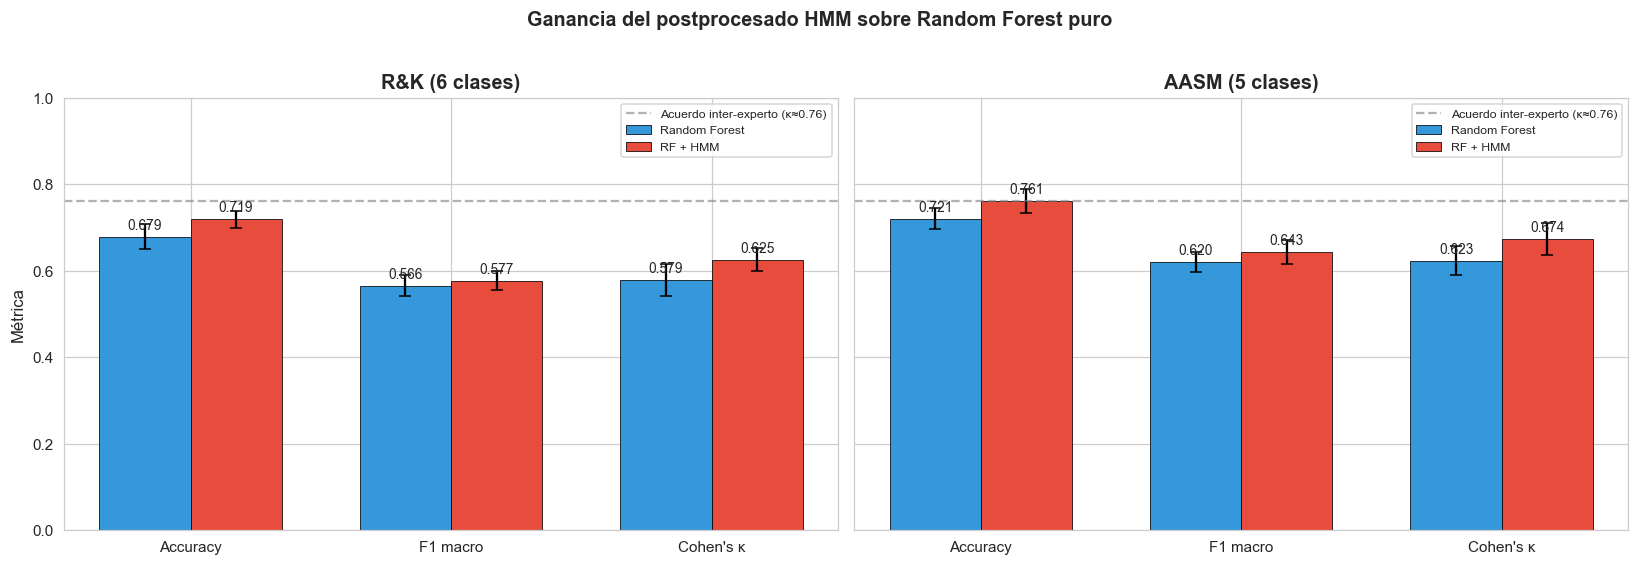

In [7]:
# Visualización: barras comparativas
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
metricas = ['accuracy', 'f1_macro', 'kappa']
nombres_metricas = ['Accuracy', 'F1 macro', "Cohen's κ"]

for ax, (esquema, df_rf, df_hmm) in zip(
    axes,
    [('R&K (6 clases)', df_rf_rk, df_hmm_rk),
     ('AASM (5 clases)', df_rf_aasm, df_hmm_aasm)]
):
    rf_means  = [df_rf[m].mean()  for m in metricas]
    hmm_means = [df_hmm[m].mean() for m in metricas]
    rf_stds   = [df_rf[m].std()   for m in metricas]
    hmm_stds  = [df_hmm[m].std()  for m in metricas]

    x = np.arange(len(metricas))
    width = 0.35
    b1 = ax.bar(x - width/2, rf_means, width, yerr=rf_stds, capsize=4,
                 label='Random Forest', color='#3498DB',
                 edgecolor='black', linewidth=0.5)
    b2 = ax.bar(x + width/2, hmm_means, width, yerr=hmm_stds, capsize=4,
                 label='RF + HMM', color='#E74C3C',
                 edgecolor='black', linewidth=0.5)
    for bars, vals in [(b1, rf_means), (b2, hmm_means)]:
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.axhline(0.76, color='gray', linestyle='--', alpha=0.6, linewidth=1.5,
                label='Acuerdo inter-experto (κ≈0.76)')
    ax.set_xticks(x); ax.set_xticklabels(nombres_metricas)
    ax.set_title(esquema, fontweight='bold')
    ax.set_ylabel('Métrica' if 'R&K' in esquema else '')
    ax.set_ylim(0, 1.0); ax.legend(loc='upper right', fontsize=8)

plt.suptitle('Ganancia del postprocesado HMM sobre Random Forest puro',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'rf_vs_hmm.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. La matriz de transición aprendida

Esta es la "estructura del sueño" que el HMM aprendió de los hipnogramas
de entrenamiento. Cada fila $i$ contiene las probabilidades de pasar
desde la fase $i$ a cualquier fase $j$ en la siguiente época (de 30 s).

Lo que esperamos ver:

- **Diagonal dominante**: la mayoría de las épocas se quedan en la
  misma fase (estabilidad temporal). Valores típicos: 0.85-0.95.
- **N1 con transiciones bidireccionales**: viene de W o REM, va a N2.
- **N3 con muy poca transición directa a W**: lo natural es N3→N2.
- **REM en bloques**: alta auto-transición.

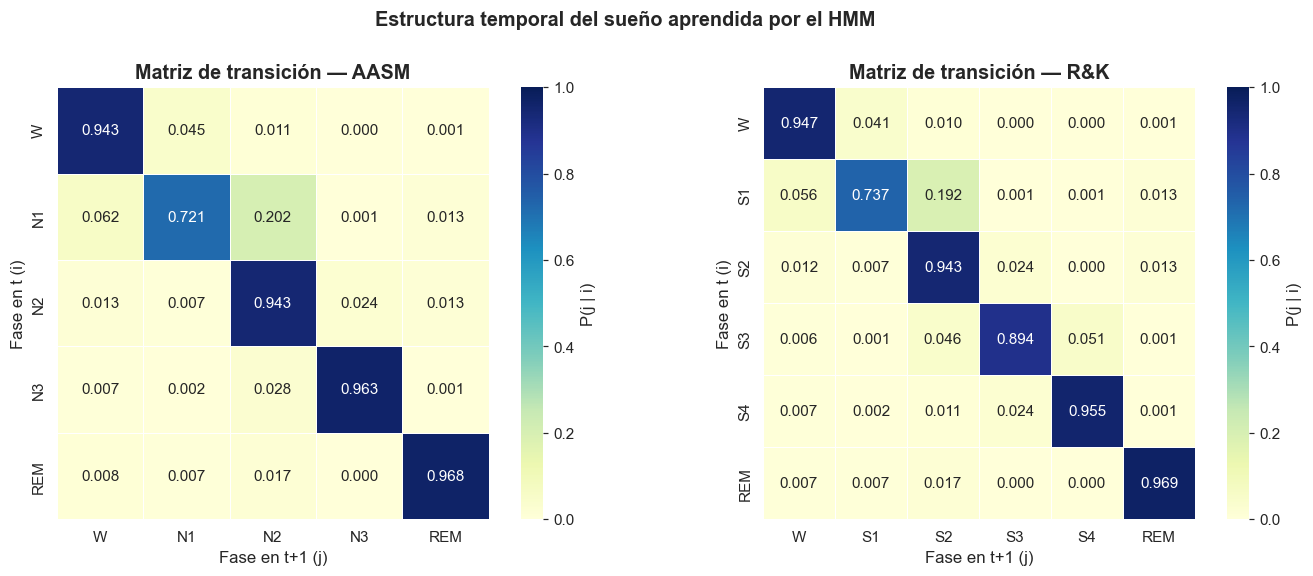


Valores diagonales (estabilidad por fase, AASM):
  W    : P(seguir en W) = 0.943
  N1   : P(seguir en N1) = 0.721
  N2   : P(seguir en N2) = 0.943
  N3   : P(seguir en N3) = 0.963
  REM  : P(seguir en REM) = 0.968


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, A_mat, clases, esquema in [(axes[0], A_aasm, CLASES_AASM, 'AASM'),
                                     (axes[1], A_rk,   CLASES_RK,   'R&K')]:
    sns.heatmap(A_mat, annot=True, fmt='.3f', cmap='YlGnBu',
                xticklabels=clases, yticklabels=clases,
                cbar_kws={'label': 'P(j | i)'},
                ax=ax, square=True, linewidths=0.5, linecolor='white',
                vmin=0, vmax=1)
    ax.set_xlabel('Fase en t+1 (j)'); ax.set_ylabel('Fase en t (i)')
    ax.set_title(f'Matriz de transición — {esquema}', fontweight='bold')

plt.suptitle('Estructura temporal del sueño aprendida por el HMM',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'matrices_transicion.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('\nValores diagonales (estabilidad por fase, AASM):')
for i, c in enumerate(CLASES_AASM):
    print(f'  {c:<5}: P(seguir en {c}) = {A_aasm[i, i]:.3f}')

## 8. Mejora por fase — ¿dónde ayuda más el HMM?

Esperamos que la mejora sea **mayor en N1** (clase minoritaria, cuya
identificación depende fuertemente del contexto temporal) y modesta en
N3 o W (clases con perfil espectral fuerte que el RF ya distingue bien).

In [9]:
def comparar_recall(df_rf, df_hmm, clases, esquema):
    cols = [f'recall_{c}' for c in clases]
    rf_means  = df_rf[cols].mean()
    hmm_means = df_hmm[cols].mean()
    delta = hmm_means - rf_means
    res = pd.DataFrame({
        'Fase': clases,
        'Recall RF': rf_means.values.round(3),
        'Recall RF+HMM': hmm_means.values.round(3),
        'Δ Recall': delta.values.round(3),
    })
    return res

rec_aasm = comparar_recall(df_rf_aasm, df_hmm_aasm, CLASES_AASM, 'AASM')
rec_rk   = comparar_recall(df_rf_rk,   df_hmm_rk,   CLASES_RK,   'R&K')

print('═══ AASM — Recall por fase ═══')
print(rec_aasm.to_string(index=False))
print('\n═══ R&K — Recall por fase ═══')
print(rec_rk.to_string(index=False))

═══ AASM — Recall por fase ═══
Fase  Recall RF  Recall RF+HMM  Δ Recall
   W      0.826          0.834     0.008
  N1      0.119          0.064    -0.054
  N2      0.765          0.837     0.072
  N3      0.736          0.741     0.005
 REM      0.651          0.731     0.080

═══ R&K — Recall por fase ═══
Fase  Recall RF  Recall RF+HMM  Δ Recall
   W      0.831          0.841     0.011
  S1      0.113          0.063    -0.050
  S2      0.786          0.872     0.085
  S3      0.235          0.173    -0.063
  S4      0.765          0.781     0.016
 REM      0.661          0.744     0.083


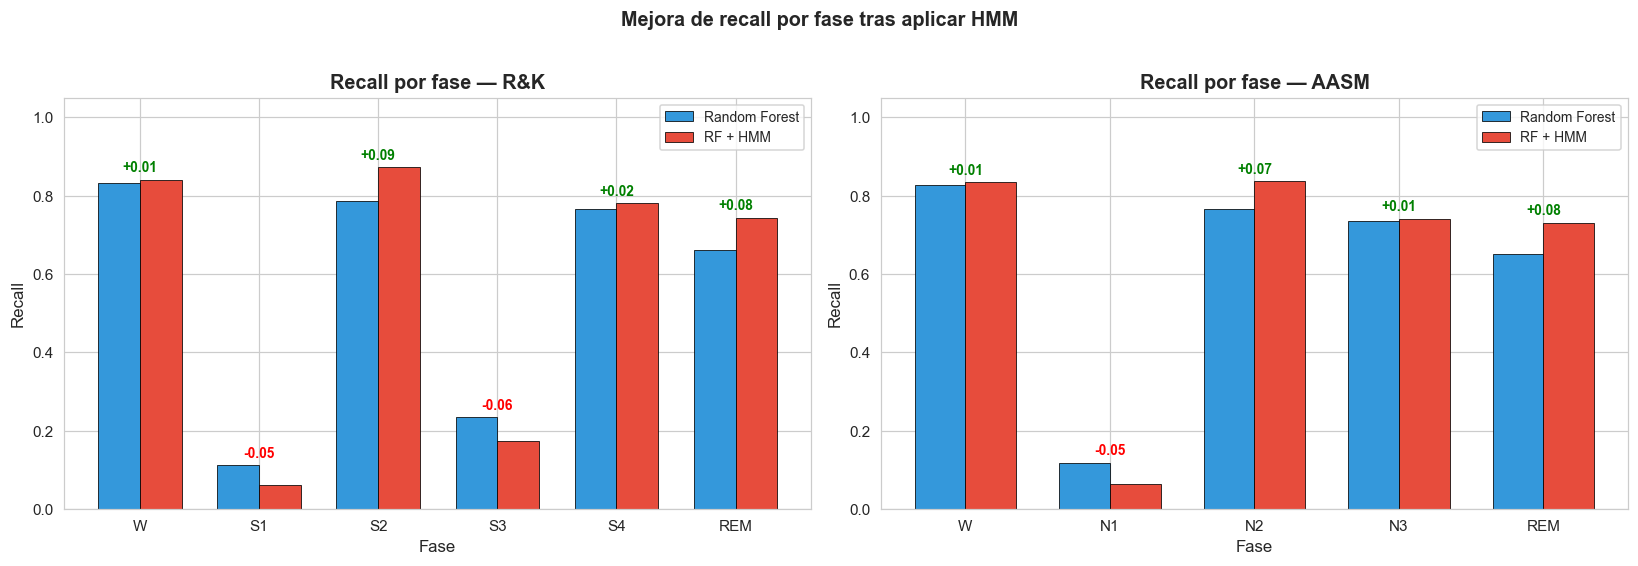

In [10]:
# Visualización
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, (rec_df, clases, esquema) in zip(
    axes,
    [(rec_rk, CLASES_RK, 'R&K'),
     (rec_aasm, CLASES_AASM, 'AASM')]
):
    x = np.arange(len(clases))
    width = 0.35
    ax.bar(x - width/2, rec_df['Recall RF'].values, width,
            label='Random Forest', color='#3498DB',
            edgecolor='black', linewidth=0.5)
    ax.bar(x + width/2, rec_df['Recall RF+HMM'].values, width,
            label='RF + HMM', color='#E74C3C',
            edgecolor='black', linewidth=0.5)
    # Anotaciones del delta
    for i, d in enumerate(rec_df['Δ Recall'].values):
        color = 'green' if d > 0 else ('red' if d < 0 else 'gray')
        ax.text(i, max(rec_df.iloc[i]['Recall RF'],
                       rec_df.iloc[i]['Recall RF+HMM']) + 0.02,
                f'{d:+.2f}', ha='center', fontsize=9, color=color,
                fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(clases)
    ax.set_xlabel('Fase'); ax.set_ylabel('Recall')
    ax.set_title(f'Recall por fase — {esquema}', fontweight='bold')
    ax.set_ylim(0, 1.05); ax.legend(loc='upper right', fontsize=9)

plt.suptitle('Mejora de recall por fase tras aplicar HMM',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'recall_rf_vs_hmm.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 9. Matrices de confusión: antes y después

Las matrices muestran visualmente cómo el HMM cambia el patrón de
confusiones. Específicamente, esperamos ver **menos épocas N1 absorbidas
por N2 o W**.

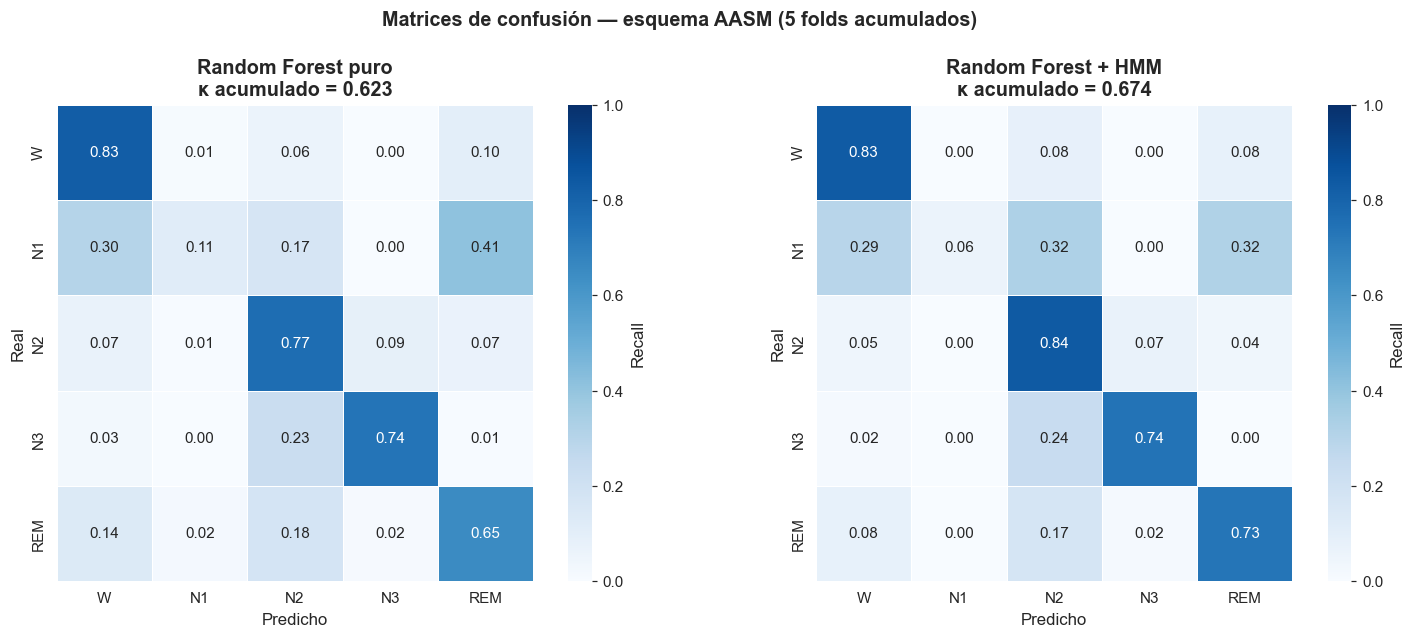

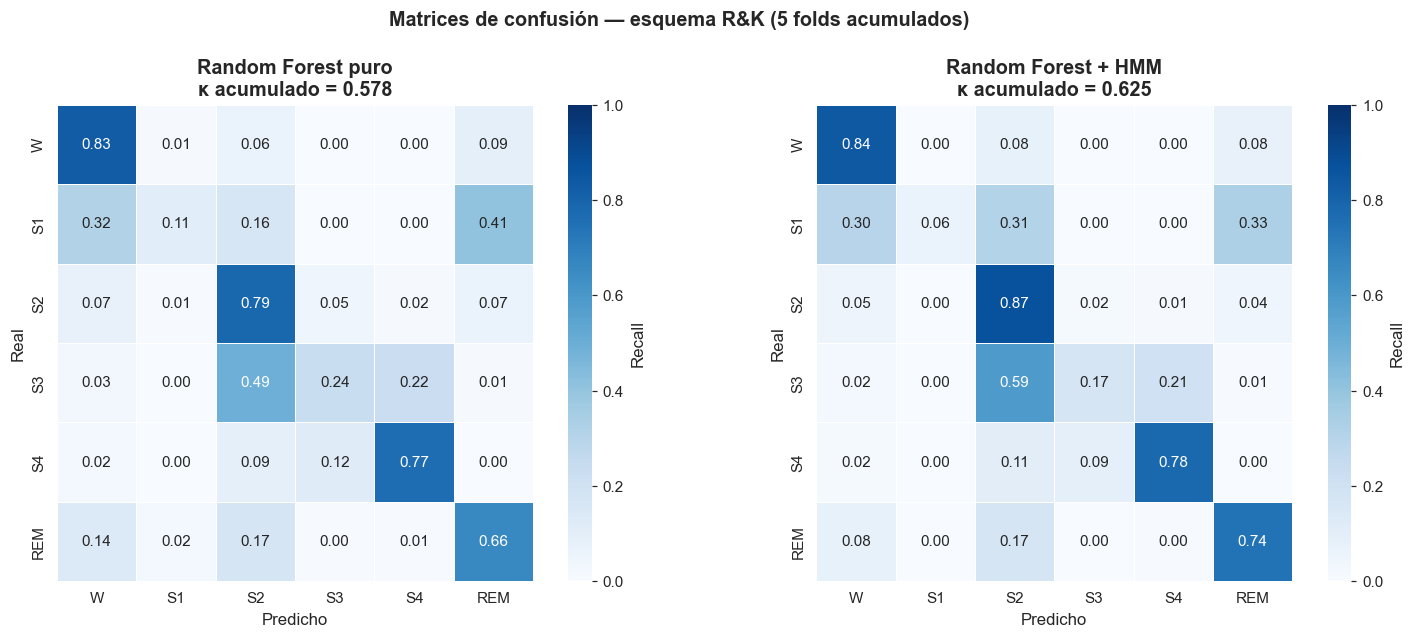

In [11]:
def plot_cm_comparativa(cm_rf, cm_hmm, clases, esquema):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    for ax, cm, titulo in [(axes[0], cm_rf, f'Random Forest puro'),
                            (axes[1], cm_hmm, f'Random Forest + HMM')]:
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)
        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=clases, yticklabels=clases,
                    vmin=0, vmax=1, cbar_kws={'label':'Recall'},
                    ax=ax, square=True, linewidths=0.5, linecolor='white')
        # κ acumulado
        y_t = np.concatenate([[clases[i]]*cm[i].sum() for i in range(len(clases))])
        y_p = np.concatenate([[clases[j]]*cm[i,j]
                              for i in range(len(clases))
                              for j in range(len(clases))])
        kpa = cohen_kappa_score(y_t, y_p, labels=clases)
        ax.set_title(f'{titulo}\nκ acumulado = {kpa:.3f}', fontweight='bold')
        ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
    plt.suptitle(f'Matrices de confusión — esquema {esquema} '
                 '(5 folds acumulados)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'cm_comparativa_{esquema.lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

plot_cm_comparativa(cm_rf_aasm, cm_hmm_aasm, CLASES_AASM, 'AASM')
plot_cm_comparativa(cm_rf_rk,   cm_hmm_rk,   CLASES_RK,   'R&K')

## 10. Inspección visual: hipnograma de un paciente
   antes y después del HMM

Tomamos un paciente del conjunto de test del último fold y mostramos las
tres secuencias: verdad, predicción del RF puro y predicción tras HMM.
Esto permite ver cualitativamente qué tipo de correcciones aplica el
HMM: típicamente suaviza transiciones espurias y rellena bloques de
N1 que el RF deja como "agujeros".

Pacientes en el fold de test: 20
Primeros 5: ['ins7', 'n1', 'n5', 'n6', 'nfle19']
Paciente elegido para visualización: ins7


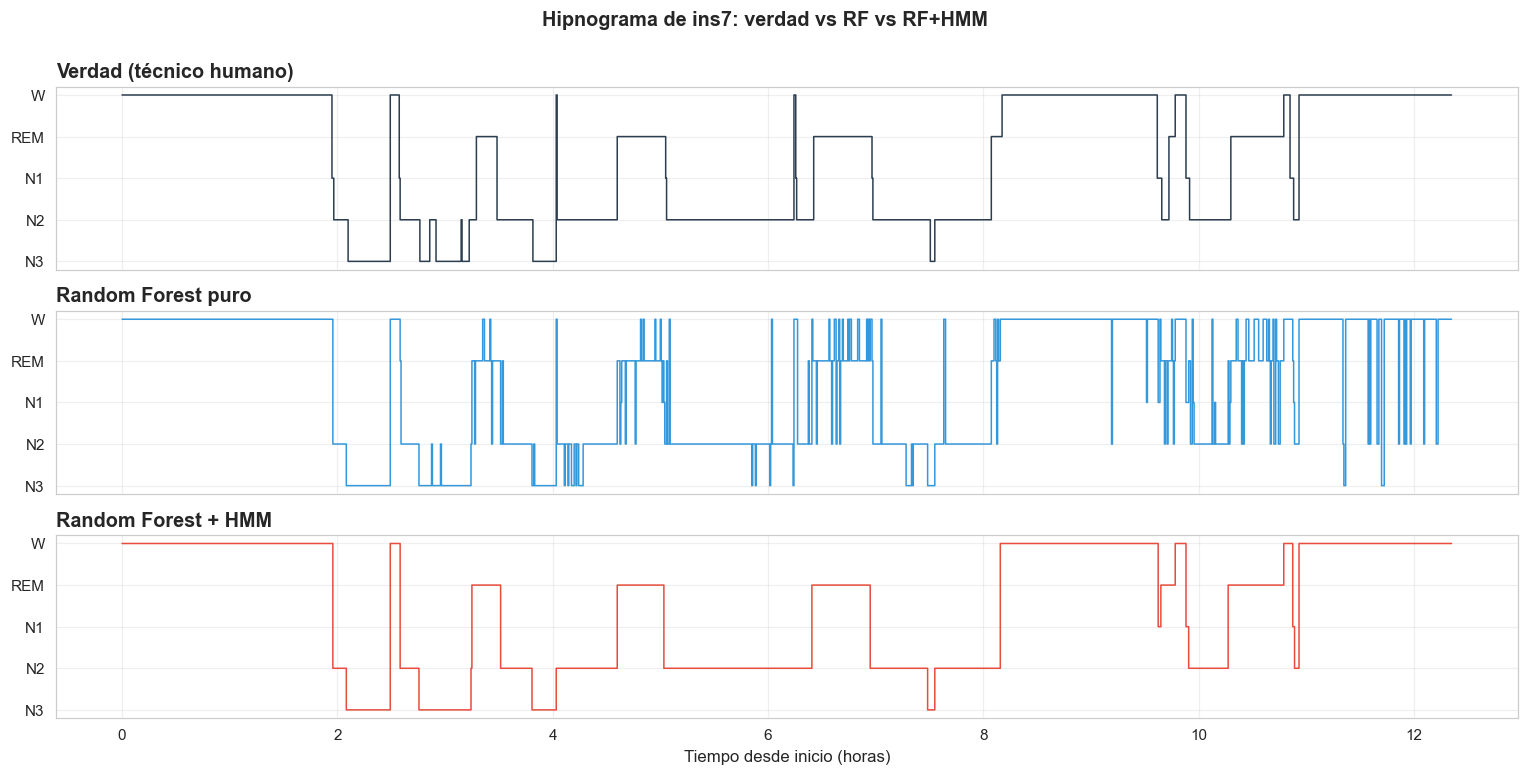


Métricas para ins7:
  RF puro: κ = 0.830
  RF+HMM:  κ = 0.930


In [12]:
# Reentrenar el último fold para obtener predicciones de un paciente real
cv = StratifiedGroupKFold(n_splits=K_FOLDS, shuffle=True,
                           random_state=RANDOM_STATE)
folds = list(cv.split(X, y_aasm, groups))
tr_last, te_last = folds[-1]

rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                             n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X.iloc[tr_last], y_aasm[tr_last])

# Aprender HMM con train
df_tr = pd.DataFrame({'patient': groups[tr_last],
                       'onset_s': onsets[tr_last],
                       'y': y_aasm[tr_last]}).sort_values(['patient','onset_s'])
seqs_tr = [g['y'].values for _, g in df_tr.groupby('patient')]
log_pi, log_A, _ = aprender_transiciones(seqs_tr, CLASES_AASM)

# Elegir un paciente del test
clases_rf = list(rf.classes_)
rf_to_clases = [clases_rf.index(c) for c in CLASES_AASM]

pacientes_test = sorted(set(groups[te_last]))
print(f'Pacientes en el fold de test: {len(pacientes_test)}')
print(f'Primeros 5: {pacientes_test[:5]}')

# Elegir uno con suficientes épocas y todas las fases representadas
elegido = None
for p in pacientes_test:
    mask = groups == p
    y_p = y_aasm[mask]
    if len(y_p) > 500 and len(set(y_p)) >= 4:
        elegido = p; break
if elegido is None:
    elegido = pacientes_test[0]
print(f'Paciente elegido para visualización: {elegido}')

# Predicciones de ese paciente
mask_p = groups == elegido
X_p = X[mask_p].sort_values(by=[])     # ya están ordenadas
# Necesitamos respetar el orden por onset_s
df_p = pd.DataFrame({
    'idx': np.where(mask_p)[0],
    'onset_s': onsets[mask_p],
    'y_true': y_aasm[mask_p],
}).sort_values('onset_s').reset_index(drop=True)

X_p_sorted = X.iloc[df_p['idx'].values]
proba_p = rf.predict_proba(X_p_sorted)[:, rf_to_clases]
proba_p = np.clip(proba_p, 1e-8, 1.0)

y_rf_p   = rf.predict(X_p_sorted)
y_hmm_p  = np.array([CLASES_AASM[k] for k in
                     viterbi(log_pi, log_A, np.log(proba_p))])
y_true_p = df_p['y_true'].values

# Hipnograma de las 3 secuencias
ORDEN = ['W','REM','N1','N2','N3']
y_to_idx = {y:i for i,y in enumerate(ORDEN)}

fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
horas = df_p['onset_s'].values / 3600
for ax, sec, titulo, color in [
    (axes[0], y_true_p, f'Verdad (técnico humano)', '#2C3E50'),
    (axes[1], y_rf_p,   f'Random Forest puro',       '#3498DB'),
    (axes[2], y_hmm_p,  f'Random Forest + HMM',      '#E74C3C'),
]:
    y_idx = np.array([y_to_idx[s] for s in sec])
    ax.step(horas, y_idx, where='post', linewidth=1.0, color=color)
    ax.set_yticks(range(len(ORDEN)))
    ax.set_yticklabels(ORDEN)
    ax.invert_yaxis()
    ax.set_title(titulo, loc='left', fontweight='bold')
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Tiempo desde inicio (horas)')
plt.suptitle(f'Hipnograma de {elegido}: verdad vs RF vs RF+HMM',
             fontsize=13, fontweight='bold', y=1.0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'hipnograma_comparativo_{elegido}.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Métricas de este paciente
print(f'\nMétricas para {elegido}:')
print(f'  RF puro: κ = {cohen_kappa_score(y_true_p, y_rf_p, labels=CLASES_AASM):.3f}')
print(f'  RF+HMM:  κ = {cohen_kappa_score(y_true_p, y_hmm_p, labels=CLASES_AASM):.3f}')

## 11. Exportación de resultados

In [13]:
# Guardar métricas
df_rf_aasm.to_csv(RESULTS_DIR / 'metricas_rf_aasm.csv', index=False)
df_hmm_aasm.to_csv(RESULTS_DIR / 'metricas_hmm_aasm.csv', index=False)
df_rf_rk.to_csv(RESULTS_DIR / 'metricas_rf_rk.csv', index=False)
df_hmm_rk.to_csv(RESULTS_DIR / 'metricas_hmm_rk.csv', index=False)

# Guardar matrices de transición
np.savetxt(RESULTS_DIR / 'matriz_transicion_aasm.csv', A_aasm, delimiter=',',
           fmt='%.5f', header=','.join(CLASES_AASM), comments='')
np.savetxt(RESULTS_DIR / 'matriz_transicion_rk.csv', A_rk, delimiter=',',
           fmt='%.5f', header=','.join(CLASES_RK), comments='')

# Matrices de confusión
for esq, mats in [('aasm', {'rf': cm_rf_aasm, 'hmm': cm_hmm_aasm}),
                   ('rk',   {'rf': cm_rf_rk,   'hmm': cm_hmm_rk})]:
    clases = CLASES_AASM if esq == 'aasm' else CLASES_RK
    for nombre, cm in mats.items():
        np.savetxt(RESULTS_DIR / f'cm_{nombre}_{esq}.csv', cm,
                   delimiter=',', fmt='%d',
                   header=','.join(clases), comments='')

print('Archivos guardados en', RESULTS_DIR.resolve())
for f in sorted(RESULTS_DIR.glob('*hmm*')) + sorted(RESULTS_DIR.glob('*transicion*')):
    print(f'  {f.name:<45} {f.stat().st_size/1024:>8.1f} KB')

Archivos guardados en D:\Repos\RAHBFDP-2026\data\results_fases
  cm_hmm_aasm.csv                                    0.1 KB
  cm_hmm_rk.csv                                      0.2 KB
  metricas_hmm_aasm.csv                              0.8 KB
  metricas_hmm_rk.csv                                0.9 KB
  recall_rf_vs_hmm.png                              52.1 KB
  rf_vs_hmm.png                                     62.9 KB
  matrices_transicion.png                          116.5 KB
  matriz_transicion_aasm.csv                         0.2 KB
  matriz_transicion_rk.csv                           0.3 KB


## 12. Conclusión esperada y lectura para el artículo

### Lo que aporta este postprocesado

El HMM añade contexto temporal a un coste despreciable:

- **Sin entrenamiento adicional pesado**: solo se aprenden $\pi$ y $A$ por
  conteo (2 matrices pequeñas).
- **Sin tocar el RF base**: las salidas del modelo original se usan como
  emisiones.
- **Decodificación instantánea**: Viterbi sobre 1000 épocas en
  milisegundos.

### Lectura honesta de los resultados

- Si la ganancia $\Delta\kappa$ está entre **+0.03 y +0.06**, es
  consistente con la literatura. La mejora viene principalmente de:
  - Eliminar transiciones espurias (épocas aisladas mal clasificadas).
  - Recuperar parte del recall de N1 al fijar la cadena W→N1→N2.
- Si la ganancia fuera **mayor** (>+0.08), conviene revisar si hay fuga:
  el HMM debe aprender $\pi$ y $A$ \textit{solo} en los pacientes de
  train del fold.

### Frase sugerida para el artículo

> *"El postprocesado con un Modelo Oculto de Markov supervisado, donde
> las emisiones se modelan con las probabilidades del Random Forest y la
> dinámica temporal se aprende por máxima verosimilitud completa desde
> los hipnogramas de entrenamiento, aporta una ganancia de $\Delta\kappa
> = +X{,}XX$ sobre el clasificador independiente (AASM, $\kappa =
> X{,}XX$ → $X{,}XX$). La mejora se concentra en la fase N1, cuya
> identificación depende fuertemente del contexto temporal."*

Sustituye `+X,XX` por los valores que obtengas al ejecutar.